In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import solve_ivp
import pandas as pd

# ── Parámetros del problema ──────────────
alpha = 0.2       # Constante de difusión térmica
L     = 1.0       # Ancho de la pared [m]
N     = 10        # Número de divisiones espaciales
dx    = L / N     # Paso espacial
T0    = 100.0     # Temperatura inicial [°C]

x = np.linspace(0, L, N+1)

print(f"α  = {alpha}")
print(f"l  = {L} m")
print(f"N  = {N}")
print(f"Δx = {dx}")
print(f"Criterio estabilidad → α²Δt/Δx² = {alpha**2 * 0.05 / dx**2:.3f} ≤ 0.5 ✔")

α  = 0.2
l  = 1.0 m
N  = 10
Δx = 0.1
Criterio estabilidad → α²Δt/Δx² = 0.200 ≤ 0.5 ✔


In [2]:
def derivs(t, T):
    dTdt = np.zeros_like(T)
    a2   = alpha**2
    dx2  = dx**2

    # Frontera fija x=0
    dTdt[0] = 0.0

    # Puntos interiores
    for i in range(1, N):
        dTdt[i] = a2 * (T[i+1] - 2*T[i] + T[i-1]) / dx2

    # Frontera aislada x=l  →  Neumann
    T_der   = (4*T[N] - T[N-1]) / 3.0
    dTdt[N] = a2 * (T_der - 2*T[N] + T[N-1]) / dx2

    return dTdt

In [3]:
def T_analitica(x, t, alpha=alpha, L=L, n_terms=50):
    T = np.zeros_like(x, dtype=float)
    for n in range(n_terms):
        k  = (2*n + 1) / (2*L) * np.pi
        T += (1/(2*n+1)) * np.sin(k*x) * np.exp(-alpha**2 * k**2 * t)
    return (400/np.pi) * T

## Python

In [ ]:
# ── Leer archivo Fortran ─────────────────
# skiprows=1 indica a numpy que ignore la primera fila del archivo
datos = np.loadtxt('FTCSPY.dat', skiprows=1)

t_py   = datos[:, 0]        # Tiempos
T_py   = datos[:, 1:N+1]    # Temperaturas T1..T10  (N puntos)
T_pyd  = datos[:, N+1]      # Temperatura frontera aislada

print(f"Pasos leídos : {len(t_py)}")
print(f"t inicio     : {t_py[0]}")
print(f"t final      : {t_py[-1]}")
print(f"Shape datos  : {T_py.shape}")

Pasos leídos : 601
t inicio     : 0.0
t final      : 30.0
Shape datos  : (601, 10)


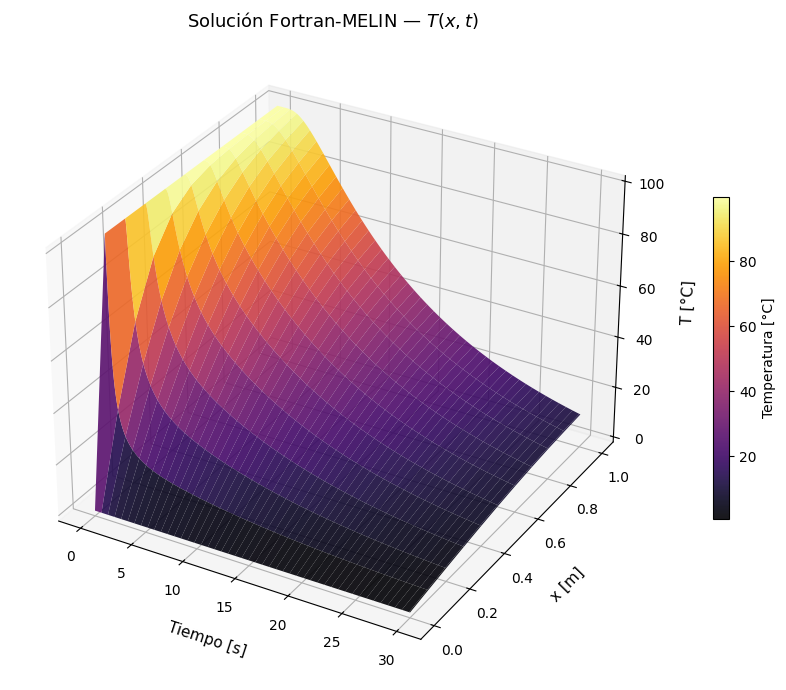

In [49]:
# x completo: 11 puntos de 0.0 a 1.0
x_py = np.linspace(0, L, N + 1)

# Z completo: concatenar T_f (10 cols) + T_fd (1 col) → shape (601, 11)
Z_grid_py = np.column_stack([T_py, T_pyd])

X_grid_py, T_grid_py = np.meshgrid(x_py, t_py)   # ambos 601×11

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid_py, X_grid_py, Z_grid_py,
                       cmap='inferno', edgecolor='none', alpha=0.9)

ax.set_xlabel('Tiempo [s]', fontsize=11, labelpad=10)
ax.set_ylabel('x [m]',      fontsize=11, labelpad=10)
ax.set_zlabel('T [°C]',     fontsize=11, labelpad=10)
ax.set_title('Solución Fortran-MELIN — $T(x,t)$', fontsize=13)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Temperatura [°C]')
plt.tight_layout()
plt.show()

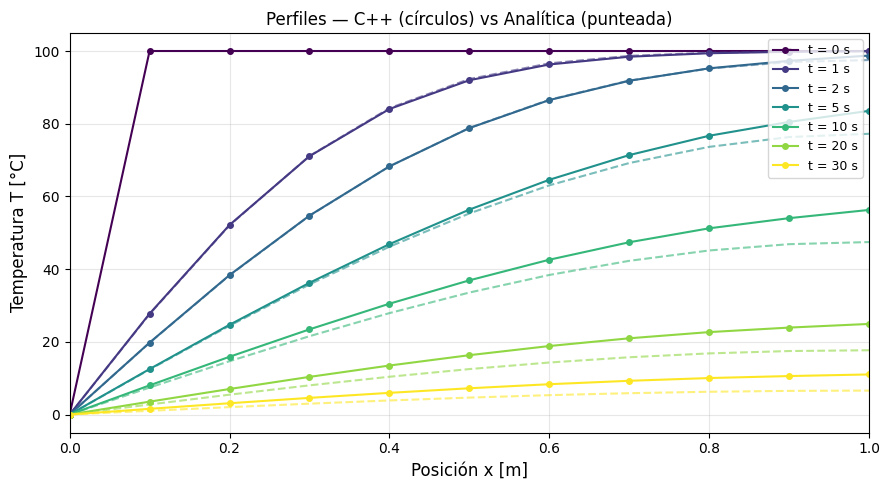

In [50]:
# ── Perfiles de temperatura C++ vs Analítica ─────────────────
tiempos_plot = [0, 1, 2, 5, 10, 20, 30]
colores      = cm.viridis(np.linspace(0, 1, len(tiempos_plot)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_plot, colores):
    idx    = np.argmin(np.abs(t_py - tp))
    T_fila = np.concatenate([T_py[idx], [T_pyd[idx]]])

    ax.plot(x_py, T_fila, '-o', color=color, markersize=4, label=f't = {tp} s')

    if tp > 0:
        ax.plot(x_py, T_analitica(x_py, tp), '--', color=color, alpha=0.6)

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Perfiles — C++ (círculos) vs Analítica (punteada)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

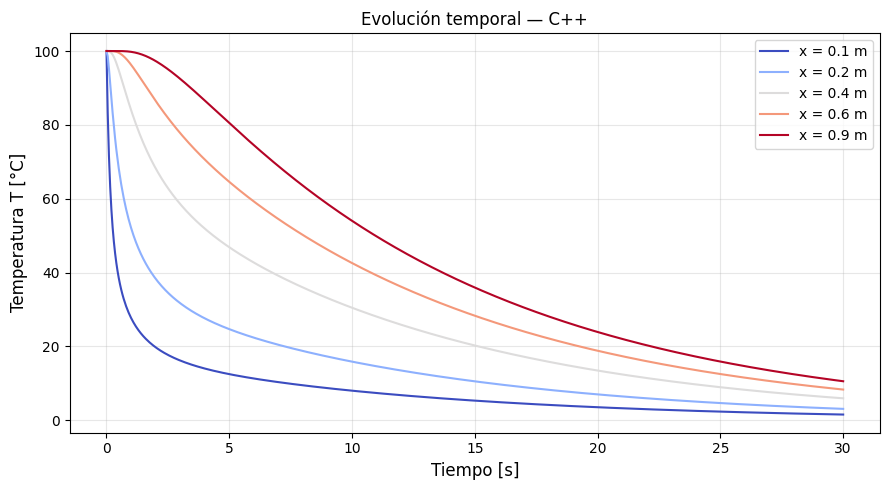

In [51]:
# ── Evolución temporal por punto C++ ─────────────────────────
puntos_cpp = [1, 2, 4, 6, 9]
colores    = cm.coolwarm(np.linspace(0, 1, len(puntos_cpp)))

fig, ax = plt.subplots(figsize=(9, 5))

for idx_x, color in zip(puntos_cpp, colores):
    ax.plot(t_py, T_py[:, idx_x], color=color,
            label=f'x = {x_py[idx_x]:.1f} m')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Evolución temporal — C++', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

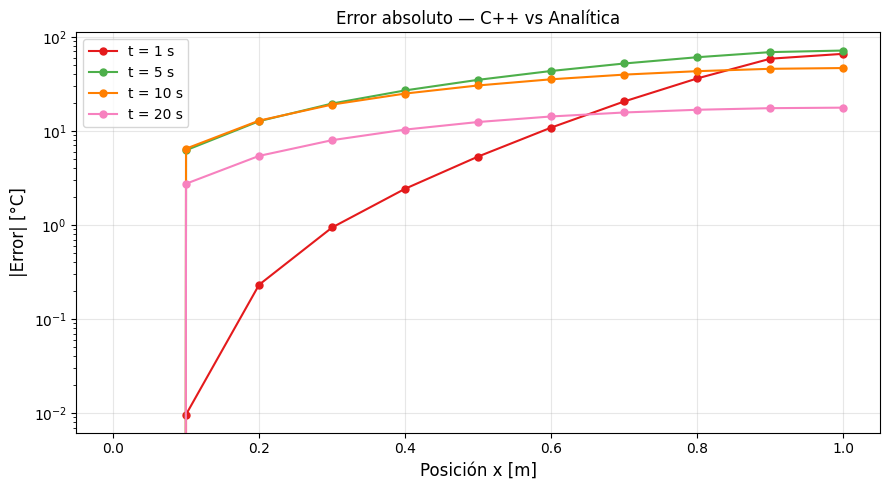

In [43]:
# ── Error absoluto C++ vs Analítica ──────────────────────────
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_error, colores):
    idx    = np.argmin(np.abs(t_py - tp))
    T_fila = np.concatenate([T_py[idx], [T_pyd[idx]]])
    err    = np.abs(T_fila - T_analitica(x_py, tp))

    ax.plot(x_py, err, '-o', color=color, markersize=5, label=f't = {tp} s')

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('|Error| [°C]', fontsize=12)
ax.set_title('Error absoluto — C++ vs Analítica', fontsize=12)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Fortran

In [ ]:
# ── Leer archivo Fortran ─────────────────
datos = np.loadtxt('FTCSF.dat', skiprows=1)

t_f   = datos[:, 0]        # Tiempos
T_f   = datos[:, 1:N+1]    # Temperaturas T1..T10  (N puntos)
T_fd  = datos[:, N+1]      # Temperatura frontera aislada

print(f"Pasos leídos : {len(t_f)}")
print(f"t inicio     : {t_f[0]}")
print(f"t final      : {t_f[-1]}")
print(f"Shape datos  : {T_f.shape}")

Pasos leídos : 601
t inicio     : 0.0
t final      : 30.0
Shape datos  : (601, 10)


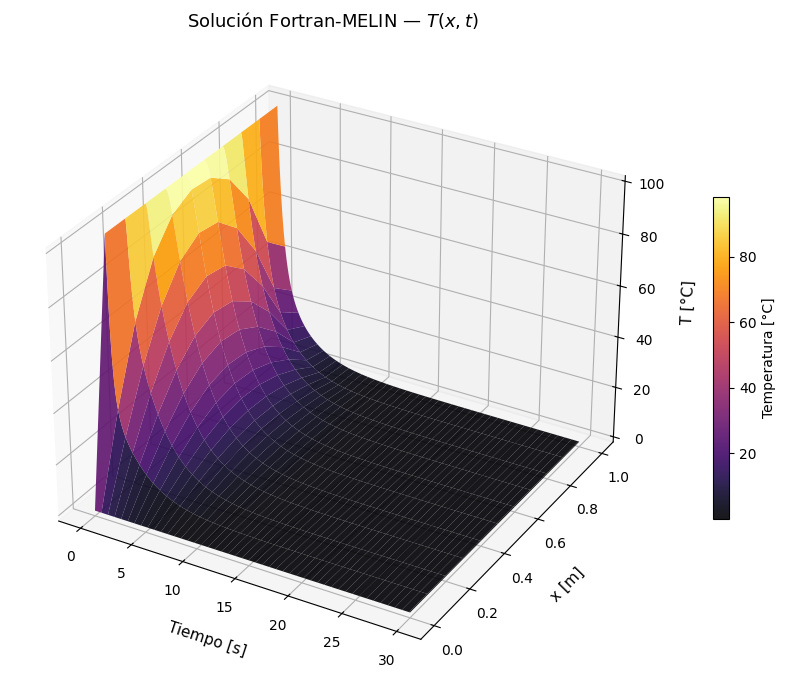

In [17]:
# x completo: 11 puntos de 0.0 a 1.0
x_f = np.linspace(0, L, N + 1)

# Z completo: concatenar T_f (10 cols) + T_fd (1 col) → shape (601, 11)
Z_grid_f = np.column_stack([T_f, T_fd])

X_grid_f, T_grid_f = np.meshgrid(x_f, t_f)   # ambos 601×11

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid_f, X_grid_f, Z_grid_f,
                       cmap='inferno', edgecolor='none', alpha=0.9)

ax.set_xlabel('Tiempo [s]', fontsize=11, labelpad=10)
ax.set_ylabel('x [m]',      fontsize=11, labelpad=10)
ax.set_zlabel('T [°C]',     fontsize=11, labelpad=10)
ax.set_title('Solución Fortran-MELIN — $T(x,t)$', fontsize=13)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Temperatura [°C]')
plt.tight_layout()
plt.show()

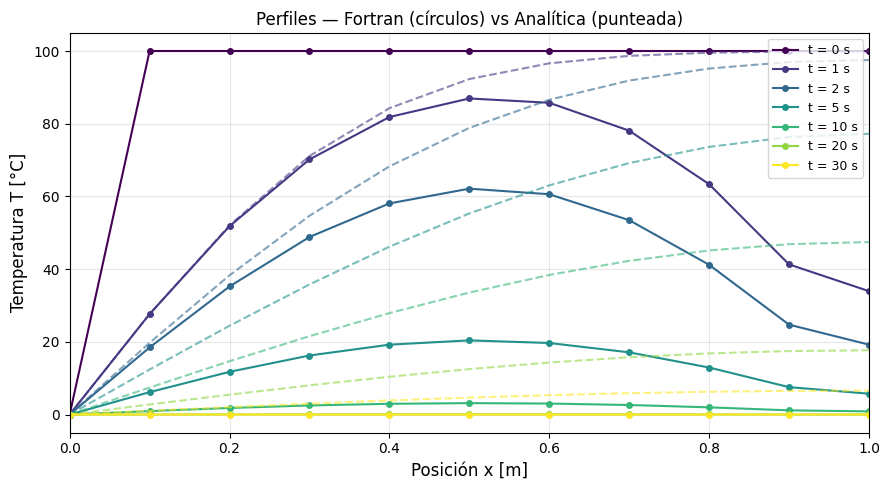

In [18]:
tiempos_plot = [0, 1, 2, 5, 10, 20, 30]
colores      = cm.viridis(np.linspace(0, 1, len(tiempos_plot)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_plot, colores):
    idx    = np.argmin(np.abs(t_f - tp))
    T_fila = np.concatenate([T_f[idx], [T_fd[idx]]])  # 10 puntos + frontera = 11

    ax.plot(x_f, T_fila, '-o', color=color, markersize=4, label=f't = {tp} s')

    if tp > 0:
        ax.plot(x_f, T_analitica(x_f, tp), '--', color=color, alpha=0.6)

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Perfiles — Fortran (círculos) vs Analítica (punteada)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

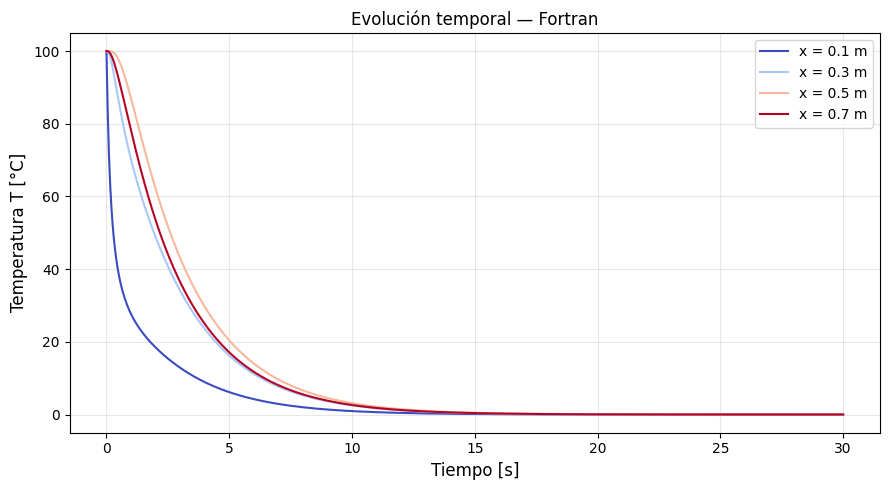

In [19]:
puntos_f = [1, 3, 5, 7]    # índices columnas de T_f
colores  = cm.coolwarm(np.linspace(0, 1, len(puntos_f)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for idx_x, color in zip(puntos_f, colores):
    ax.plot(t_f, T_f[:, idx_x], color=color,
            label=f'x = {x_f[idx_x]:.1f} m')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Evolución temporal — Fortran', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

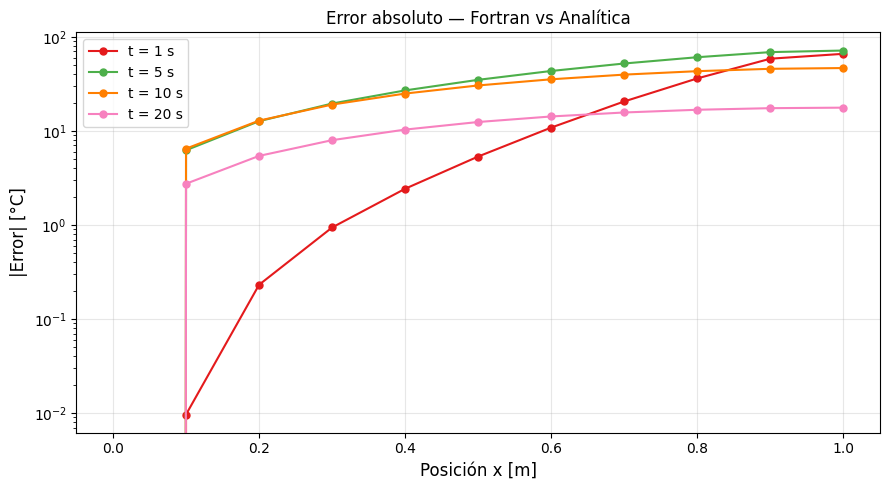

In [20]:
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

x_f = np.linspace(0, L, N + 1)   # 11 puntos: 0.0, 0.1, ..., 1.0

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_error, colores):
    idx    = np.argmin(np.abs(t_f - tp))
    T_fila = np.concatenate([T_f[idx], [T_fd[idx]]])  # 10 puntos + frontera = 11
    err    = np.abs(T_fila - T_analitica(x_f, tp))

    ax.plot(x_f, err, '-o', color=color, markersize=5, label=f't = {tp} s')

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('|Error| [°C]', fontsize=12)
ax.set_title('Error absoluto — Fortran vs Analítica', fontsize=12)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
t_tabla = 5.0
idx     = np.argmin(np.abs(t_f - t_tabla))
T_fila  = np.concatenate([[0.0], T_f[idx]])
T_an    = T_analitica(x, t_tabla)

df_f = pd.DataFrame({
    'x [m]'       : np.round(x,                      2),
    'T Fortran'   : np.round(T_fila,                  4),
    'T analítico' : np.round(T_an,                    4),
    '|Error|'     : np.round(np.abs(T_fila - T_an),   6)
})

display(df_f)

,x [m],T Fortran,T analítico,|Error|
0,0.0,0.0000,0.0000,0.000000
1,0.1,0.0000,12.3869,12.386873
2,0.2,6.1599,24.4248,18.264906
3,0.3,11.7468,35.7830,24.036243
4,0.4,16.2400,46.1647,29.924652
5,0.5,19.2195,55.3176,36.098089
6,0.6,20.4043,63.0401,42.635807
7,0.7,19.6802,69.1806,49.500356
8,0.8,17.1107,73.6327,56.522019
9,0.9,12.9328,76.3286,63.395824


## C++

In [ ]:
# ── Leer archivo C++ ─────────────────────────────────────────
datos_cpp = np.loadtxt('FTCSCPP.dat', skiprows=1)

t_cpp  = datos_cpp[:, 0]
T_cpp  = datos_cpp[:, 1:N+1]
T_cpd  = datos_cpp[:, N+1]

x_cpp = np.linspace(0, L, N + 1)

print(f"Pasos leídos : {len(t_cpp)}")
print(f"t inicio     : {t_cpp[0]}")
print(f"t final      : {t_cpp[-1]}")
print(f"Shape datos  : {T_cpp.shape}")

Pasos leídos : 601
t inicio     : 0.0
t final      : 30.0
Shape datos  : (601, 10)


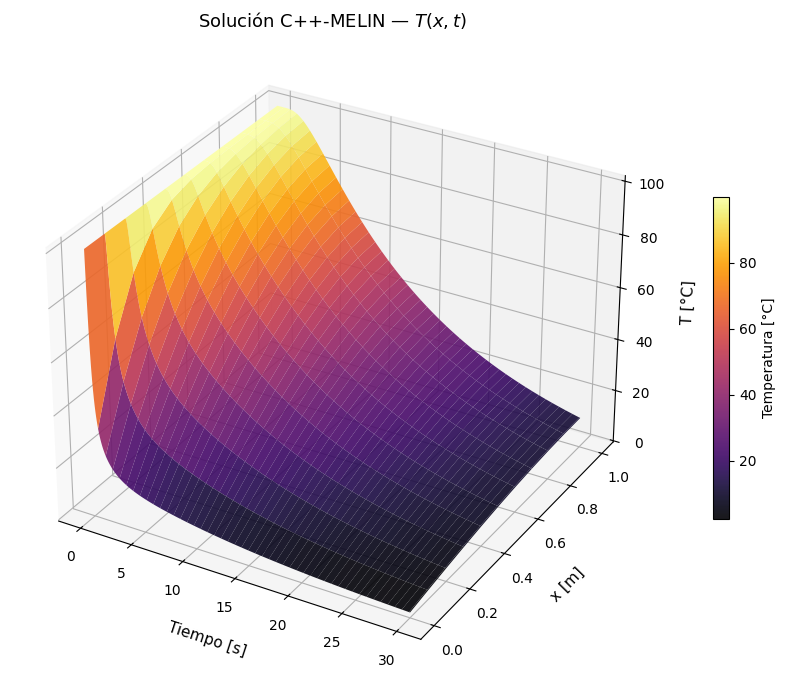

In [58]:
# ── Superficie 3D C++ ────────────────────────────────────────
Z_grid_cpp = np.column_stack([T_cpp, T_cpd])
X_grid_cpp, T_grid_cpp = np.meshgrid(x_cpp, t_cpp)

fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(T_grid_cpp, X_grid_cpp, Z_grid_cpp,
                       cmap='inferno', edgecolor='none', alpha=0.9)

ax.set_xlabel('Tiempo [s]', fontsize=11, labelpad=10)
ax.set_ylabel('x [m]',      fontsize=11, labelpad=10)
ax.set_zlabel('T [°C]',     fontsize=11, labelpad=10)
ax.set_title('Solución C++-MELIN — $T(x,t)$', fontsize=13)
fig.colorbar(surf, ax=ax, shrink=0.5, label='Temperatura [°C]')
plt.tight_layout()
plt.show()

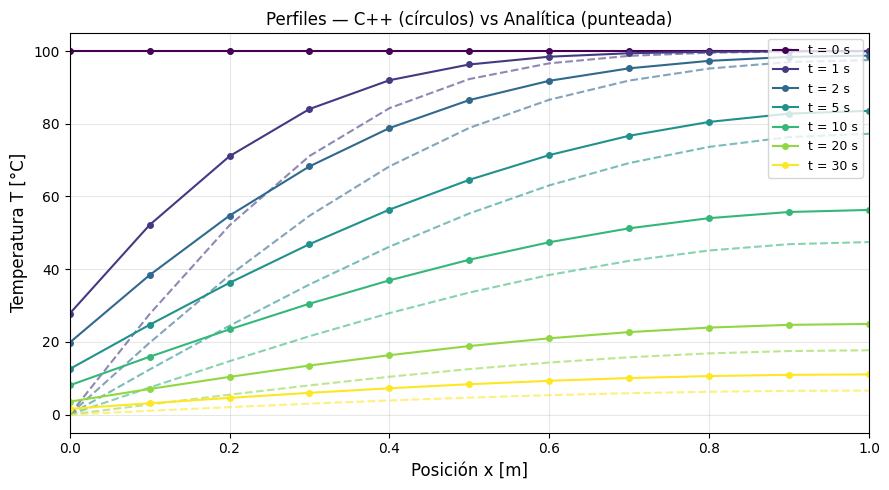

In [59]:
# ── Perfiles de temperatura C++ vs Analítica ─────────────────
tiempos_plot = [0, 1, 2, 5, 10, 20, 30]
colores      = cm.viridis(np.linspace(0, 1, len(tiempos_plot)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_plot, colores):
    idx    = np.argmin(np.abs(t_cpp - tp))
    T_fila = np.concatenate([T_cpp[idx], [T_cpd[idx]]])

    ax.plot(x_cpp, T_fila, '-o', color=color, markersize=4, label=f't = {tp} s')

    if tp > 0:
        ax.plot(x_cpp, T_analitica(x_cpp, tp), '--', color=color, alpha=0.6)

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Perfiles — C++ (círculos) vs Analítica (punteada)', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, L)
ax.set_ylim(-5, 105)
plt.tight_layout()
plt.show()

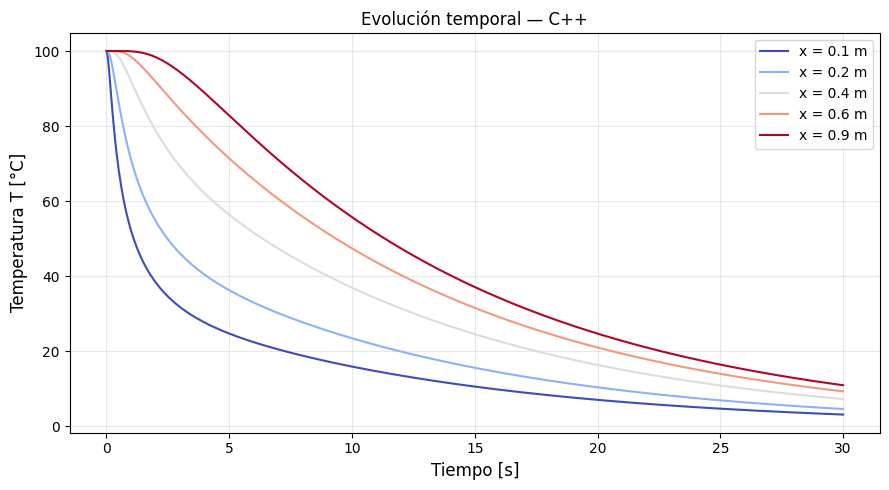

In [60]:
# ── Evolución temporal por punto C++ ─────────────────────────
puntos_cpp = [1, 2, 4, 6, 9]
colores    = cm.coolwarm(np.linspace(0, 1, len(puntos_cpp)))

fig, ax = plt.subplots(figsize=(9, 5))

for idx_x, color in zip(puntos_cpp, colores):
    ax.plot(t_cpp, T_cpp[:, idx_x], color=color,
            label=f'x = {x_cpp[idx_x]:.1f} m')

ax.set_xlabel('Tiempo [s]', fontsize=12)
ax.set_ylabel('Temperatura T [°C]', fontsize=12)
ax.set_title('Evolución temporal — C++', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

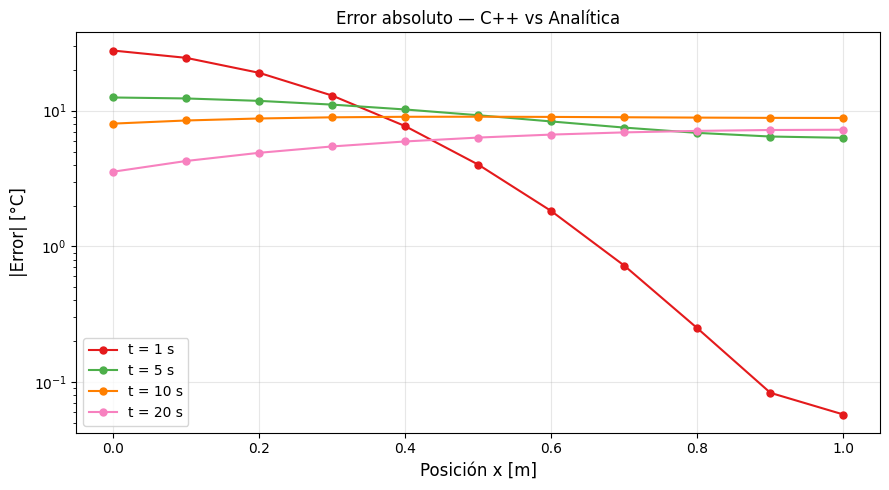

In [61]:
# ── Error absoluto C++ vs Analítica ──────────────────────────
tiempos_error = [1, 5, 10, 20]
colores       = cm.Set1(np.linspace(0, 0.8, len(tiempos_error)))

fig, ax = plt.subplots(figsize=(9, 5))

for tp, color in zip(tiempos_error, colores):
    idx    = np.argmin(np.abs(t_cpp - tp))
    T_fila = np.concatenate([T_cpp[idx], [T_cpd[idx]]])
    err    = np.abs(T_fila - T_analitica(x_cpp, tp))

    ax.plot(x_cpp, err, '-o', color=color, markersize=5, label=f't = {tp} s')

ax.set_xlabel('Posición x [m]', fontsize=12)
ax.set_ylabel('|Error| [°C]', fontsize=12)
ax.set_title('Error absoluto — C++ vs Analítica', fontsize=12)
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# ── Tabla comparativa C++ en t=5s ────────────────────────────
t_tabla    = 5.0
idx        = np.argmin(np.abs(t_cpp - t_tabla))
T_fila_cpp = np.concatenate([T_cpp[idx], [T_cpd[idx]]])
T_an       = T_analitica(x_cpp, t_tabla)

df_cpp = pd.DataFrame({
    'x [m]'       : np.round(x_cpp,                        2),
    'T C++'        : np.round(T_fila_cpp,                   4),
    'T analítico'  : np.round(T_an,                         4),
    '|Error|'      : np.round(np.abs(T_fila_cpp - T_an),    6)
})

display(df_cpp)

,x [m],T C++,T analítico,|Error|
0,0.0,0.0000,0.0000,0.000000
1,0.1,6.1599,12.3869,6.226973
2,0.2,11.7468,24.4248,12.678006
3,0.3,16.2400,35.7830,19.543043
4,0.4,19.2195,46.1647,26.945152
5,0.5,20.4043,55.3176,34.913289
6,0.6,19.6802,63.0401,43.359907
7,0.7,17.1107,69.1806,52.069856
8,0.8,12.9328,73.6327,60.699919
9,0.9,7.5360,76.3286,68.792624
